# Análisis de cráteres — Marte

Este notebook realiza el análisis exploratorio completo del dataset de cráteres marcianos.

**Orden de ejecución:** ejecuta las celdas de arriba hacia abajo.

In [1]:
# ── 1. Importaciones ──────────────────────────────────────────────────────
import sys, os
sys.path.insert(0, os.path.abspath('..'))

from src.data_loader          import cargar_dataset
from src.preprocessor         import preprocesar_dataset
from src.stats_analyzer       import estadisticas_descriptivas, generar_histogramas, matriz_correlacion
from src.correlation_analyzer import scatter_plot, comparar_correlaciones
from src.plot_generator       import panel_resumen, scatter_regresion
from src.map_builder          import construir_mapa_marte

In [2]:
# ── 2. Carga del dataset ──────────────────────────────────────────────────
df_marte = cargar_dataset('../data/marte_crateres.csv', planeta='marte')
df_marte.head()

/home/Adrian/Documents/UEM/Proyecto-Ingenieria/Marte/files/proyecto_crateres/src/data_loader.py:71: DtypeWarning: Columns (0: LAY_NUMBER, 1: LAY_MORPH1, 2: LAY_MORPH2, 3: LAY_MORPH3, 4: LAY_NOTES, 5: INT_MORPH1, 6: INT_MORPH2, 7: INT_MORPH3, 8: CONF, 9: NOTES) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(ruta_csv)


[AVISO] Columna 'DEPTH_RIMFLOOR_TOPOG' no encontrada en el CSV. Se creó vacía. El análisis de profundidad se omitirá.
[OK] Dataset 'marte' cargado desde '../data/marte_crateres.csv'.
     Registros: 385,049  |  Columnas: 36


,CRATER_ID,LATITUDE_CIRCLE_IMAGE,LONGITUDE_CIRCLE_IMAGE,LAT_ELLI_IMG,LON_ELLI_IMG,DIAM_CIRCLE_IMAGE,DIAM_CIRC_SD_IMG,DIAM_ELLI_MAJOR_IMG,DIAM_ELLI_MINOR_IMG,DIAM_ELLI_ECCEN_IMG,...,INT_MORPH1,INT_MORPH2,INT_MORPH3,CONF,NOTES,DEG_RIM,DEG_EJC,DEG_FLR,DEPTH_RIMFLOOR_TOPOG,ERR_CIRCLE_IMAGE
0,01-1-000003,79.257599,211.909949,79.257584,211.910021,19.526698,0.230187,19.746718,19.286041,0.214742,...,CpxUnc,NaN,Floor Deposits,NaN,NaN,1.0,1.0,1.0,<NA>,<NA>
1,01-1-000004,78.696512,207.162344,78.696517,207.162105,4.232291,0.089167,4.449180,4.019798,0.428605,...,NaN,NaN,Floor Deposits,NaN,NaN,3.0,2.0,1.0,<NA>,<NA>
2,01-1-000012,77.791422,186.586023,77.791443,186.585690,8.542042,0.193030,8.818632,8.251528,0.352817,...,CpxFF,NaN,NaN,NaN,NaN,2.0,2.0,2.0,<NA>,<NA>
3,01-1-000013,76.655040,194.807812,76.655020,194.807973,7.967843,0.139290,8.268589,7.662693,0.375745,...,CpxFF,NaN,NaN,NaN,NaN,3.0,2.0,3.0,<NA>,<NA>
4,01-1-000014,76.976285,195.615795,76.976294,195.616254,20.948878,0.340399,21.550893,20.326902,0.332212,...,CpxFF,NaN,Floor Deposits,NaN,NaN,3.0,2.0,3.0,<NA>,<NA>


In [3]:
# ── 3. Preprocesamiento ───────────────────────────────────────────────────
df_marte = preprocesar_dataset(df_marte, planeta='marte')
df_marte.head()

[AVISO] 'DEPTH_RIMFLOOR_TOPOG' sin datos. 'log_depth' se creó vacío.
[OK] Preprocesamiento completado para 'marte'.
     Registros válidos: 385,049  (eliminados por nulos: 0)


,CRATER_ID,LATITUDE_CIRCLE_IMAGE,LONGITUDE_CIRCLE_IMAGE,LAT_ELLI_IMG,LON_ELLI_IMG,DIAM_CIRCLE_IMAGE,DIAM_CIRC_SD_IMG,DIAM_ELLI_MAJOR_IMG,DIAM_ELLI_MINOR_IMG,DIAM_ELLI_ECCEN_IMG,...,CONF,NOTES,DEG_RIM,DEG_EJC,DEG_FLR,DEPTH_RIMFLOOR_TOPOG,ERR_CIRCLE_IMAGE,log_diam,log_depth,has_layers
0,01-1-000003,79.257599,211.909949,79.257584,211.910021,19.526698,0.230187,19.746718,19.286041,0.214742,...,NaN,NaN,1.0,1.0,1.0,<NA>,<NA>,3.021726,NaN,0
1,01-1-000004,78.696512,207.162344,78.696517,207.162105,4.232291,0.089167,4.449180,4.019798,0.428605,...,NaN,NaN,3.0,2.0,1.0,<NA>,<NA>,1.654849,NaN,0
2,01-1-000012,77.791422,186.586023,77.791443,186.585690,8.542042,0.193030,8.818632,8.251528,0.352817,...,NaN,NaN,2.0,2.0,2.0,<NA>,<NA>,2.255707,NaN,0
3,01-1-000013,76.655040,194.807812,76.655020,194.807973,7.967843,0.139290,8.268589,7.662693,0.375745,...,NaN,NaN,3.0,2.0,3.0,<NA>,<NA>,2.193645,NaN,1
4,01-1-000014,76.976285,195.615795,76.976294,195.616254,20.948878,0.340399,21.550893,20.326902,0.332212,...,NaN,NaN,3.0,2.0,3.0,<NA>,<NA>,3.088716,NaN,0


In [4]:
# ── 4. Estadísticas descriptivas ──────────────────────────────────────────
# Filtrar solo columnas con datos disponibles
variables_disponibles = [v for v in ['DIAM_CIRCLE_IMAGE', 'DEPTH_RIMFLOOR_TOPOG', 'NUMBER_LAYERS']
                         if df_marte[v].notna().any()]
print(f'Variables con datos: {variables_disponibles}')
estadisticas_descriptivas(df_marte, variables_disponibles)

Variables con datos: ['DIAM_CIRCLE_IMAGE', 'NUMBER_LAYERS']


,DIAM_CIRCLE_IMAGE,NUMBER_LAYERS
count,385049.000000,19746.000000
mean,3.555495,1.262787
std,8.524536,0.545401
min,1.000001,1.000000
25%,1.184636,1.000000
50%,1.526114,1.000000
75%,2.554618,1.000000
max,1088.024257,5.000000


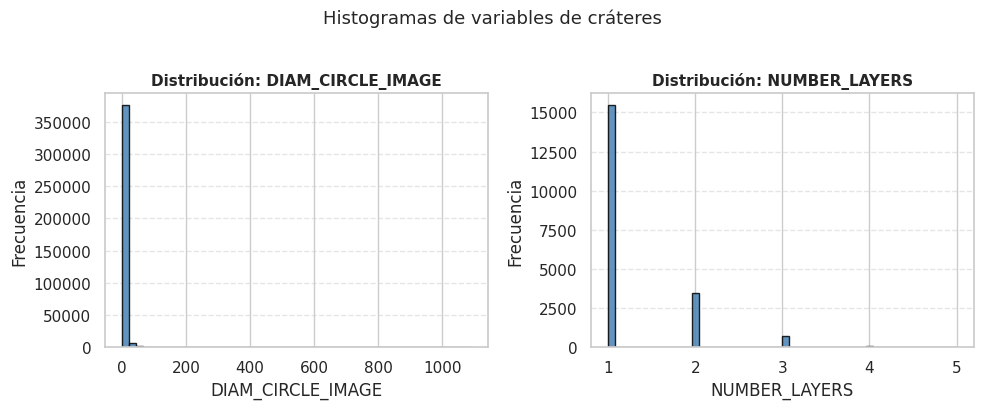

In [5]:
# ── 5. Histogramas de distribución ────────────────────────────────────────
# Filtrar solo columnas con datos
vars_hist = [v for v in ['DIAM_CIRCLE_IMAGE', 'DEPTH_RIMFLOOR_TOPOG', 'NUMBER_LAYERS']
             if df_marte[v].notna().any()]
if vars_hist:
    generar_histogramas(df_marte, vars_hist)
else:
    print('[AVISO] No hay variables numéricas con datos para histogramas.')

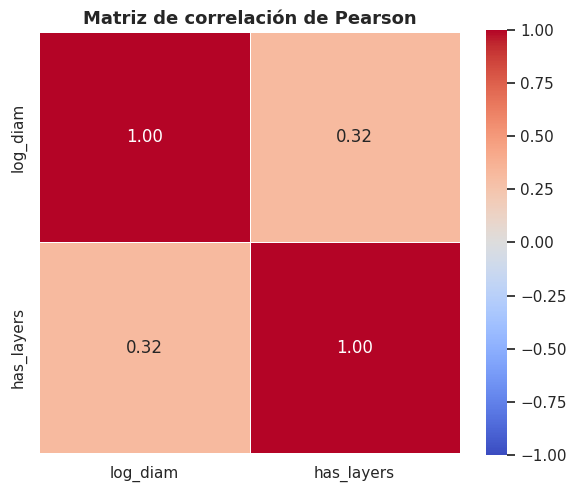

In [6]:
# ── 6. Matriz de correlación ──────────────────────────────────────────────
# Filtrar solo variables derivadas con datos
vars_corr = [v for v in ['log_diam', 'log_depth', 'has_layers']
             if v in df_marte.columns and df_marte[v].notna().any()]
if len(vars_corr) >= 2:
    matriz_correlacion(df_marte, vars_corr)
else:
    print('[AVISO] Variables insuficientes para matriz de correlación.')

In [7]:
# ── 7. Scatter con regresión ──────────────────────────────────────────────
# Solo ejecutar si log_depth tiene datos
if df_marte['log_depth'].notna().any():
    scatter_regresion(df_marte, x='log_diam', y='log_depth')
else:
    print('[AVISO] Scatter log_diam vs log_depth omitido: profundidad no disponible en este dataset.')

[AVISO] Scatter log_diam vs log_depth omitido: profundidad no disponible en este dataset.


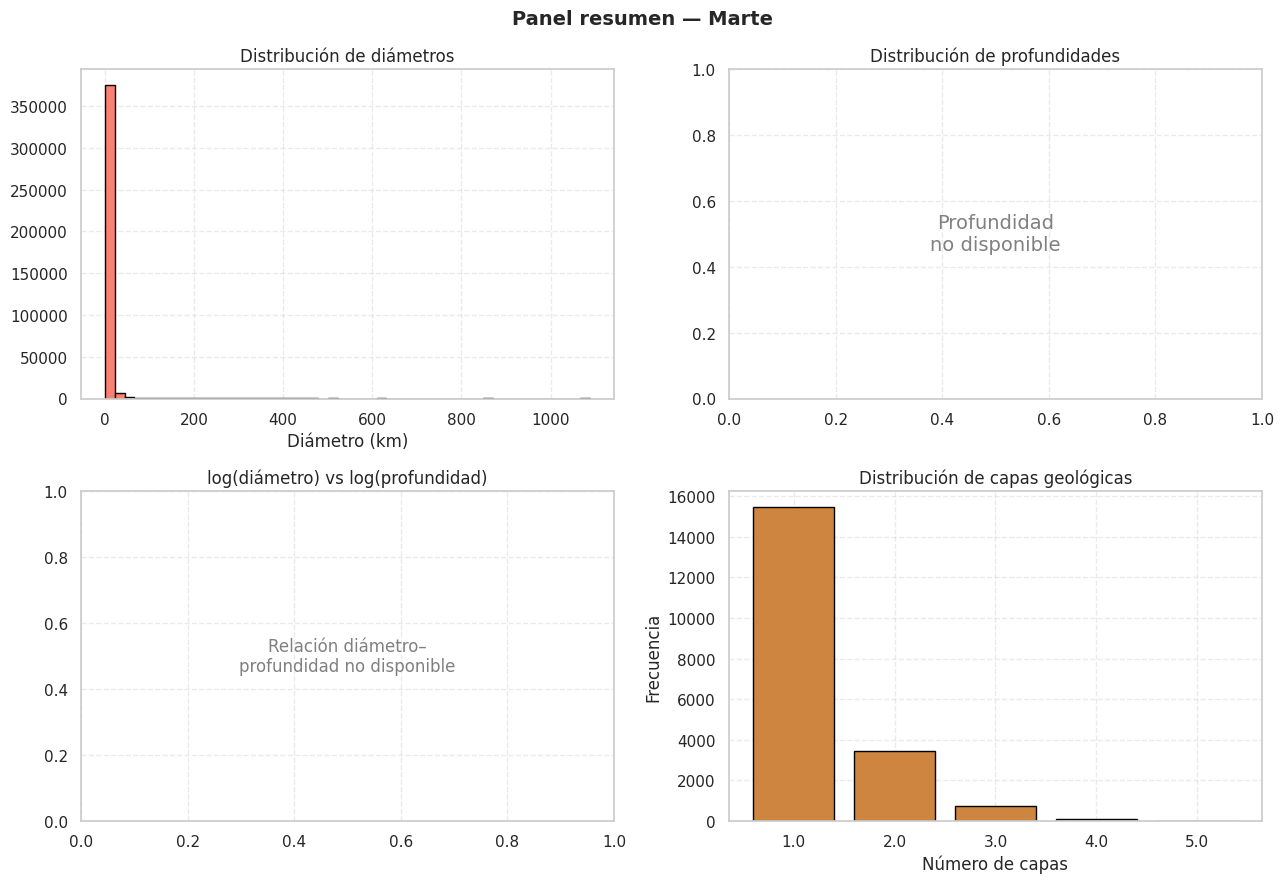

In [8]:
# ── 8. Panel resumen ──────────────────────────────────────────────────────
panel_resumen(df_marte, planeta='marte')

In [9]:
# ── 9. Mapa interactivo ───────────────────────────────────────────────────
mapa_marte = construir_mapa_marte(df_marte, max_crateres=500)
mapa_marte  # Mostrar el mapa inline

[OK] Mapa marciano generado con 500 cráteres.


In [10]:
# ── 10. Exportar mapa a HTML ──────────────────────────────────────────────
mapa_marte.save('mapa_marte.html')
print('Mapa exportado a mapa_marte.html')

Mapa exportado a mapa_marte.html
